# EDA

## Загрузка и первичный осмотр данных
*Что делаем:*
Загружаем две таблицы: data_df (транзакции, пользователи, товары, логистика, отзывы) и events_df (события кликов/просмотров). Выводим размеры, типы колонок, количество непустых значений, примеры строк и уникальные значения в статусах заказов и типах событий.

*Зачем:*
Понять структуру данных, объём, качество (пропуски, дубликаты, выбросы), а также выявить очевидные проблемы (например, полностью пустые колонки). Это необходимо для планирования дальнейшей очистки и создания признаков.

*Почему так:*
Без первичного анализа можно пропустить важные особенности (например, что sold_at на 100% пустая), что приведёт к ошибкам на следующих этапах.

In [2]:
import pandas as pd
data_path = "../data/raw/data.csv"
events_path = "../data/raw/events.csv"

data_df = pd.read_csv(data_path)
events_df = pd.read_csv(events_path)

In [3]:
import numpy as np

print("=== data_df ===")
print(f"Размер: {data_df.shape}")
print(data_df.info())
print("\nПервые 2 строки:")
print(data_df.head(2))

print("\n=== events_df ===")
print(f"Размер: {events_df.shape}")
print(events_df.info())
print("\nПервые 2 строки:")
print(events_df.head(2))

# Дополнительно: уникальные значения в статусах и типах событий
print("\nСтатусы заказов:", data_df['status'].unique())
print("Типы событий:", events_df['event_type'].unique())

=== data_df ===
Размер: (545778, 49)
<class 'pandas.DataFrame'>
RangeIndex: 545778 entries, 0 to 545777
Data columns (total 49 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   order_id                        545778 non-null  int64  
 1   user_id                         545778 non-null  int64  
 2   status                          545778 non-null  str    
 3   gender                          545778 non-null  str    
 4   created_at                      545778 non-null  str    
 5   returned_at                     54174 non-null   str    
 6   shipped_at                      354054 non-null  str    
 7   delivered_at                    190125 non-null  str    
 8   num_of_item                     545778 non-null  int64  
 9   product_id                      545778 non-null  int64  
 10  inventory_item_id               545778 non-null  int64  
 11  sale_price                      545778 non-null  flo

## Приведение типов данных
*Что делаем:*
Преобразуем строковые даты в тип datetime, числовые поля (цены, возраст, количество товаров) – в float64/int64, логическое поле is_loyal – в int (0/1).

*Зачем:*
Для корректного вычисления разницы между датами (например, срок доставки) и использования признаков в моделях (требуются числовые типы).

*Почему так:*
Если оставить даты как строки, мы не сможем вычислить recency или delivery_days. Нечисловые значения в age или sale_price приведут к ошибкам в модели.

In [4]:
# Копируем данные, чтобы не испортить исходные
data = data_df.copy()
events = events_df.copy()

# Даты в data
date_cols = ['created_at', 'returned_at', 'shipped_at', 'delivered_at']
for col in date_cols:
    data[col] = pd.to_datetime(data[col], errors='coerce')

# Дата в events
events['created_at'] = pd.to_datetime(events['created_at'], errors='coerce')

# Числовые колонки
numeric_cols = ['sale_price', 'retail_price', 'cost', 'age', 'num_of_item']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# is_loyal: bool -> int
data['is_loyal'] = data['is_loyal'].astype(int)

# Проверка типов после преобразования
print("Типы в data после приведения:")
print(data.dtypes.value_counts())
print("\nТипы в events после приведения:")
print(events.dtypes.value_counts())

Типы в data после приведения:
str                    25
int64                  11
float64                 9
datetime64[us, UTC]     4
Name: count, dtype: int64

Типы в events после приведения:
str                    9
int64                  2
float64                1
datetime64[us, UTC]    1
Name: count, dtype: int64


## Обработка пропусков
*Что делаем:*

- Удаляем полностью пустую колонку sold_at.
- Создаём флаги is_returned (есть ли дата возврата) и is_delivered (есть ли дата доставки).
- Заполняем отсутствующие отзывы значением 0 (нет отзыва).
- Пропуски в возрасте заполняем медианой по полу, затем общей медианой.
- Категориальные поля (город, бренд и т.д.) заполняем строкой 'Unknown'.
- В таблице событий удаляем строки без user_id (они не привязаны к клиенту).

*Зачем:*
Модели и статистические расчёты не работают с пропусками. Нужно либо удалить строки, либо заполнить пропуски осмысленными значениями. Выбор стратегии зависит от смысла данных.

*Почему так:*
- sold_at бесполезна – удаляем.
- Флаги возврата/доставки – полезные признаки.
- Отсутствие отзыва – норма, поэтому 0.
- Возраст заполняем медианой, чтобы не искажать среднее выбросами.
- 'Unknown' для категорий – стандартный подход.
- События без user_id нельзя привязать к клиенту – они бесполезны для персонализации.

In [5]:
# Удаляем бесполезную колонку
if 'sold_at' in data.columns:
    data.drop(columns=['sold_at'], inplace=True)

# Флаги
data['is_returned'] = data['returned_at'].notna().astype(int)
data['is_delivered'] = data['delivered_at'].notna().astype(int)

# Отзывы
data['customer_review'] = data['customer_review'].fillna(0)

# Возраст
data['gender'] = data['gender'].fillna('Unknown')
data['age'] = data.groupby('gender')['age'].transform(lambda x: x.fillna(x.median()))
data['age'] = data['age'].fillna(data['age'].median())

# Категориальные поля
categorical_cols = ['city', 'brand', 'product_brand', 'department', 'product_category',
                    'product_department', 'warehouse_name', 'traffic_source', 'state', 'country']
for col in categorical_cols:
    if col in data.columns:
        data[col] = data[col].fillna('Unknown')

# Числовые пропуски (retail_price, cost)
for col in ['retail_price', 'cost']:
    if col in data.columns:
        data[col] = data[col].fillna(data[col].median())

# Обработка events: удаляем строки без user_id
before = len(events)
events = events[events['user_id'].notna()].copy()
events['user_id'] = events['user_id'].astype(int)
after = len(events)
print(f"События: удалено {before - after} строк без user_id ({(before-after)/before*100:.1f}%)")

# Проверка пропусков после обработки
print("\nПропуски в data после обработки:")
print(data.isnull().sum().sum())
print("Пропуски в events после обработки:")
print(events.isnull().sum().sum())

События: удалено 2248488 строк без user_id (46.2%)

Пропуски в data после обработки:
1247580
Пропуски в events после обработки:
90306


## Выявление и корректировка выбросов
*Что делаем:*
Обрезаем экстремальные значения в sale_price, age, num_of_item по 1-му и 99-му перцентилям (клиппинг).

*Зачем:*
Выбросы (например, цена 1 000 000) могут сильно исказить средние значения и ухудшить качество модели.

*Почему так:*
Клиппинг сохраняет строки (не теряем данные), но ограничивает влияние аномалий. Для цен и возраста 1–99 перцентили – разумный диапазон.

In [6]:
def cap_outliers(df, column, lower_perc=0.01, upper_perc=0.99):
    lower = df[column].quantile(lower_perc)
    upper = df[column].quantile(upper_perc)
    df[column] = df[column].clip(lower, upper)
    return df

# Применяем
data = cap_outliers(data, 'sale_price', 0.01, 0.99)
data = cap_outliers(data, 'age', 0.01, 0.99)
data = cap_outliers(data, 'num_of_item', 0, 0.99)  # нижнюю границу не трогаем

# Проверка границ
print("После клиппинга:")
print(f"sale_price: min={data['sale_price'].min():.2f}, max={data['sale_price'].max():.2f}")
print(f"age: min={data['age'].min()}, max={data['age'].max()}")
print(f"num_of_item: min={data['num_of_item'].min()}, max={data['num_of_item'].max()}")

После клиппинга:
sale_price: min=6.49, max=300.00
age: min=12, max=70
num_of_item: min=1, max=4


 ## Создание признаков: RFM-сегментация
 *Что делаем:*
На основе завершённых заказов (status == 'Complete') вычисляем для каждого пользователя:
- recency – дней с последней покупки,
- frequency – количество заказов,
- monetary – сумма трат.
Затем делим на квартили, присваиваем скоры 1–4 (4 – лучший) и формируем сегмент (строка из трёх цифр).

*Зачем:*
RFM – классический метод оценки ценности клиента. Он позволяет выделить лояльных, «спящих», новых и проблемных клиентов без сложного ML.

*Почему так:*
Только завершённые заказы гарантируют, что покупка действительно состоялась. Квартили дают относительную оценку внутри базы, что устойчиво к масштабу.

In [7]:
# Только завершённые заказы
completed = data[data['status'] == 'Complete'].copy()
if len(completed) == 0:
    raise ValueError("Нет завершённых заказов!")

# Текущая дата (максимальная дата в данных + 1 день)
current_date = completed['created_at'].max() + pd.Timedelta(days=1)

rfm = completed.groupby('user_id').agg(
    recency=('created_at', lambda x: (current_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('sale_price', 'sum')
).reset_index()

# RFM-скоры (квартили)
rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1], duplicates='drop')
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4], duplicates='drop')
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4], duplicates='drop')
rfm['RFM_segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print(f"RFM: {len(rfm)} пользователей с завершёнными заказами.")
print(rfm.head())

RFM: 27473 пользователей с завершёнными заказами.
   user_id  recency  frequency     monetary R_score F_score M_score  \
0        1    513.0          1   166.470005       2       1       2   
1        2    334.0          1   372.000000       3       1       3   
2       12      1.0          1    41.250000       4       1       1   
3       14    258.0          2  1130.939999       3       4       4   
4       17   1273.0          1   254.849991       1       1       3   

  RFM_segment  
0       2.012  
1       3.013  
2       4.011  
3       3.044  
4       1.013  


## Признаки: частота возвратов, доставка, поведенческие события, демография

*Что делаем:*

- Возвраты: считаем общее число заказов и число возвратов, вычисляем долю return_rate (ограничиваем 1.0).
- Доставка: для заказов с обеими датами вычисляем delivery_days, затем среднее, максимум, стандартное отклонение по пользователю. Если данных нет – заполняем значениями по умолчанию.
- События: агрегируем по пользователю: общее число событий, уникальные сессии, дни с последнего события, а также отдельные счётчики по типам (event_cart, event_purchase и др.).
- Демография: берём уникальные значения возраста, пола, лояльности, источника трафика, штата, города.

*Зачем:*
Эти признаки описывают поведение клиента вне покупок (активность на сайте), его лояльность (возвраты), качество обслуживания (доставка) и социально-демографический профиль. Все они потенциально влияют на отток.

*Почему так:*

- Возвраты нормализованы на число заказов, чтобы сравнить клиентов с разной активностью.
- Доставка – важна, но в синтетических данных её почти нет, поэтому мы используем запасные значения.
- Поведенческие признаки – ключевой сигнал «засыпания» клиента.
- Демография – стандартные атрибуты для сегментации.

In [8]:
# Возвраты
returns = data.groupby('user_id').agg(
    total_orders_all=('order_id', 'nunique'),
    returns_count=('returned_at', lambda x: x.notna().sum())
).reset_index()
returns['return_rate'] = returns['returns_count'] / returns['total_orders_all']
returns['return_rate'] = returns['return_rate'].fillna(0).clip(upper=1)

# Доставка
delivered = data[data['shipped_at'].notna() & data['delivered_at'].notna()].copy()
if len(delivered) > 0:
    delivered['delivery_days'] = (delivered['delivered_at'] - delivered['shipped_at']).dt.days
    delivery = delivered.groupby('user_id')['delivery_days'].agg(
        avg_delivery_days='mean',
        max_delivery_days='max',
        std_delivery_days='std'
    ).reset_index()
    avg_del = delivered['delivery_days'].mean()
    delivery['avg_delivery_days'] = delivery['avg_delivery_days'].fillna(avg_del)
    delivery['max_delivery_days'] = delivery['max_delivery_days'].fillna(avg_del + 2)
    delivery['std_delivery_days'] = delivery['std_delivery_days'].fillna(0)
else:
    delivery = pd.DataFrame(columns=['user_id', 'avg_delivery_days', 'max_delivery_days', 'std_delivery_days'])

# События
if len(events) > 0:
    events_agg = events.groupby('user_id').agg(
        total_events=('event_type', 'count'),
        unique_sessions=('session_id', 'nunique'),
        last_event_date=('created_at', 'max')
    ).reset_index()
    current_date_events = events['created_at'].max() + pd.Timedelta(days=1)
    events_agg['days_since_last_event'] = (current_date_events - events_agg['last_event_date']).dt.days
    # Pivot по типам
    event_pivot = events.groupby(['user_id', 'event_type']).size().unstack(fill_value=0).reset_index()
    event_pivot.columns = ['user_id'] + [f'event_{col}' for col in event_pivot.columns[1:]]
    events_features = events_agg.merge(event_pivot, on='user_id', how='left')
    for col in event_pivot.columns[1:]:
        events_features[col] = events_features[col].fillna(0)
else:
    events_features = pd.DataFrame(columns=['user_id', 'total_events', 'unique_sessions', 'days_since_last_event'])

# Демография
demo = data[['user_id', 'age', 'gender', 'is_loyal', 'traffic_source', 'state', 'city']].drop_duplicates('user_id')
demo['is_loyal'] = demo['is_loyal'].astype(int)

print("Таблицы признаков созданы.")
print(f"Размер returns: {returns.shape}")
print(f"Размер delivery: {delivery.shape}")
print(f"Размер events_features: {events_features.shape}")
print(f"Размер demo: {demo.shape}")

Таблицы признаков созданы.
Размер returns: (80021, 4)
Размер delivery: (0, 4)
Размер events_features: (80021, 10)
Размер demo: (80021, 7)


## Сборка итоговой таблицы features_full

*Что делаем:*

- Объединяем всех пользователей из data и events (даже тех, кто не покупал).
- Присоединяем все созданные признаки через merge по user_id.
- Заполняем оставшиеся пропуски (например, у тех, у кого нет событий или доставки).
- Преобразуем категориальные признаки (gender, traffic_source, state, city, RFM_segment) в числовые с помощью LabelEncoder.
- Удаляем служебные колонки (даты, user_id при необходимости).

*Зачем:*
Получаем единую таблицу «один пользователь – одна строка» со всеми признаками, готовую для моделирования и визуализации. Без пропусков и с числовыми типами.

*Почему так:*

- Объединение всех пользователей гарантирует, что мы не потеряем тех, кто зарегистрировался, но ничего не купил (их отток – высок).
- Заполнение пропусков осмысленными значениями (999 для recency, 0 для frequency) – стандарт.
- LabelEncoder преобразует строки в числа, сохраняя порядок (для некоторых признаков порядок не важен, но это допустимо).

In [9]:
# Все уникальные user_id из data и events
all_users = pd.concat([data['user_id'], events['user_id']]).drop_duplicates().reset_index(drop=True)
features_full = all_users.to_frame(name='user_id')

# Объединяем
features_full = features_full.merge(rfm, on='user_id', how='left')
features_full = features_full.merge(returns, on='user_id', how='left')
features_full = features_full.merge(delivery, on='user_id', how='left')
features_full = features_full.merge(events_features, on='user_id', how='left')
features_full = features_full.merge(demo, on='user_id', how='left')

# Заполняем пропуски
features_full['recency'] = features_full['recency'].fillna(999)
features_full['frequency'] = features_full['frequency'].fillna(0)
features_full['monetary'] = features_full['monetary'].fillna(0)
features_full['R_score'] = features_full['R_score'].fillna(1)
features_full['F_score'] = features_full['F_score'].fillna(1)
features_full['M_score'] = features_full['M_score'].fillna(1)
features_full['RFM_segment'] = features_full['RFM_segment'].fillna('111')
features_full['return_rate'] = features_full['return_rate'].fillna(0)
features_full['returns_count'] = features_full['returns_count'].fillna(0)
features_full['total_orders_all'] = features_full['total_orders_all'].fillna(0)

# Доставка
for col in ['avg_delivery_days', 'max_delivery_days', 'std_delivery_days']:
    if col in features_full.columns:
        features_full[col] = features_full[col].fillna(7 if col=='avg_delivery_days' else 14 if col=='max_delivery_days' else 0)

# События
features_full['total_events'] = features_full['total_events'].fillna(0)
features_full['unique_sessions'] = features_full['unique_sessions'].fillna(0)
features_full['days_since_last_event'] = features_full['days_since_last_event'].fillna(999)
for col in event_pivot.columns[1:]:
    if col in features_full.columns:
        features_full[col] = features_full[col].fillna(0)
    else:
        features_full[col] = 0

# Демография
features_full['age'] = features_full['age'].fillna(features_full['age'].median())
features_full['gender'] = features_full['gender'].fillna('Unknown')
features_full['traffic_source'] = features_full['traffic_source'].fillna('Unknown')
features_full['state'] = features_full['state'].fillna('Unknown')
features_full['city'] = features_full['city'].fillna('Unknown')

# Кодируем категориальные
from sklearn.preprocessing import LabelEncoder
categorical_cols = ['gender', 'traffic_source', 'state', 'city', 'RFM_segment']
for col in categorical_cols:
    le = LabelEncoder()
    features_full[col] = features_full[col].astype(str)
    features_full[col] = le.fit_transform(features_full[col])

# Удаляем ненужные колонки (дата последнего события, если есть)
if 'last_event_date' in features_full.columns:
    features_full.drop(columns=['last_event_date'], inplace=True)

# Проверка
print(f"Итоговый размер features_full: {features_full.shape}")
print(f"Пропуски: {features_full.isnull().sum().sum()}")
print(f"Типы:\n{features_full.dtypes.value_counts()}")

Итоговый размер features_full: (80021, 28)
Пропуски: 0
Типы:
int64       17
float64      5
object       3
category     2
category     1
Name: count, dtype: int64


Принудительно преобразуем все колонки в числовые:

In [10]:
# Преобразование всех нечисловых колонок в числовые
for col in features_full.columns:
    if features_full[col].dtype in ['object', 'category']:
        features_full[col] = pd.to_numeric(features_full[col], errors='coerce').fillna(0).astype(int)

## ABC-анализ товаров (для рекомендаций)
*Что делаем:*
На основе завершённых заказов группируем товары по выручке, сортируем по убыванию, вычисляем кумулятивный процент и присваиваем классы:
- A – товары, дающие 80% выручки,
- B – следующие 15%,
- C – последние 5%.

*Зачем:*
Классификация товаров помогает рекомендательной системе предлагать самые популярные и прибыльные позиции, особенно для клиентов с высоким риском оттока (чтобы реактивировать их).

*Почему так:*
Закон Парето (80/20) часто работает в e-commerce. Классы A, B, C – интуитивно понятны бизнесу.

In [11]:
# На основе завершённых заказов
product_sales = completed.groupby('product_id').agg(total_revenue=('sale_price', 'sum')).reset_index()
product_sales = product_sales.sort_values('total_revenue', ascending=False)
product_sales['cumsum_revenue'] = product_sales['total_revenue'].cumsum()
product_sales['cumsum_percent'] = product_sales['cumsum_revenue'] / product_sales['total_revenue'].sum() * 100

def abc_class(pct):
    if pct <= 80:
        return 'A'
    elif pct <= 95:
        return 'B'
    else:
        return 'C'

product_sales['abc_class'] = product_sales['cumsum_percent'].apply(abc_class)
print(product_sales['abc_class'].value_counts())
product_sales.head()

abc_class
A    9985
B    7017
C    5818
Name: count, dtype: int64


,product_id,total_revenue,cumsum_revenue,cumsum_percent,abc_class
18882,24325,5688.000000,5688.000000,0.072010,A
18752,24170,5400.000000,11088.000000,0.140374,A
18983,24447,5400.000000,16488.000000,0.208738,A
15526,20233,4679.819824,21167.819824,0.267984,A
17631,22812,4500.000000,25667.819824,0.324954,A


## Сохранение результатов

In [12]:
features_full.to_csv('features_full.csv', index=False)
product_sales.to_csv('product_abc.csv', index=False)
print("Файлы сохранены: features_full.csv, product_abc.csv")

Файлы сохранены: features_full.csv, product_abc.csv


# Разработка прогнозных моделей

## Подготовка данных с временным разделением
*Что делаем:*
Определяем дату отсечения (90 дней до последней даты в данных). Все признаки строим только на данных до отсечения, а целевую переменную (отток) определяем по наличию покупок после отсечения. Это исключает утечку информации из будущего.

*Зачем:*
Чтобы модель обучалась на реальных исторических данных и могла предсказывать отток на будущее, не «подглядывая» в ответ.

*Почему 90 дней:*
Стандартный горизонт для e-commerce — клиент, не купивший ничего за 90 дней, считается «уснувшим» и с высокой вероятностью ушёл.

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Предполагается, что переменные data и events уже созданы в пункте 1
# (очищенные данные, не исходные)

# Определяем последнюю дату в данных
last_date = data['created_at'].max()
cutoff_date = last_date - pd.Timedelta(days=90)
print(f"Последняя дата в данных: {last_date}")
print(f"Дата отсечения (обучение на данных ДО): {cutoff_date}")

# Фильтруем данные для обучения (до отсечения)
data_train = data[data['created_at'] <= cutoff_date].copy()
events_train = events[events['created_at'] <= cutoff_date].copy()

# Данные после отсечения (для определения оттока)
data_future = data[data['created_at'] > cutoff_date].copy()

# Список пользователей, активных до отсечения
active_users_before = data_train['user_id'].unique()
print(f"Активных пользователей до отсечения: {len(active_users_before)}")

# Кто из них совершал покупки после отсечения (любой статус Complete)
users_with_purchase_after = data_future[data_future['status'] == 'Complete']['user_id'].unique()

# Целевая переменная: 1 если отток (нет покупок после), 0 если лояльный
churn_dict = {user: (0 if user in users_with_purchase_after else 1) for user in active_users_before}

Последняя дата в данных: 2026-03-11 00:47:27+00:00
Дата отсечения (обучение на данных ДО): 2025-12-11 00:47:27+00:00
Активных пользователей до отсечения: 69016


## Создание признаков на данных ДО отсечения

*Что делаем:*
Повторяем создание признаков (RFM, возвраты, доставка, события, демография), но только на данных data_train и events_train. Это гарантирует, что модель не увидит будущих данных.

*Зачем:*
Без этого шага модель бы «знала» то, что произошло после отсечения, что привело бы к завышенной оценке качества (утечка).

In [14]:
# 2.1 RFM на train
completed_train = data_train[data_train['status'] == 'Complete'].copy()
if len(completed_train) > 0:
    current_date_train = completed_train['created_at'].max() + pd.Timedelta(days=1)
    rfm_train = completed_train.groupby('user_id').agg(
        recency=('created_at', lambda x: (current_date_train - x.max()).days),
        frequency=('order_id', 'nunique'),
        monetary=('sale_price', 'sum')
    ).reset_index()
    rfm_train['R_score'] = pd.qcut(rfm_train['recency'], 4, labels=[4,3,2,1], duplicates='drop')
    rfm_train['F_score'] = pd.qcut(rfm_train['frequency'].rank(method='first'), 4, labels=[1,2,3,4], duplicates='drop')
    rfm_train['M_score'] = pd.qcut(rfm_train['monetary'], 4, labels=[1,2,3,4], duplicates='drop')
    rfm_train['RFM_segment'] = rfm_train['R_score'].astype(str) + rfm_train['F_score'].astype(str) + rfm_train['M_score'].astype(str)
else:
    rfm_train = pd.DataFrame(columns=['user_id','recency','frequency','monetary','R_score','F_score','M_score','RFM_segment'])

# 2.2 Возвраты
returns_train = data_train.groupby('user_id').agg(
    total_orders_all=('order_id', 'nunique'),
    returns_count=('returned_at', lambda x: x.notna().sum())
).reset_index()
returns_train['return_rate'] = returns_train['returns_count'] / returns_train['total_orders_all']
returns_train['return_rate'] = returns_train['return_rate'].fillna(0).clip(upper=1)

# 2.3 Доставка (если есть данные)
delivered_train = data_train[data_train['shipped_at'].notna() & data_train['delivered_at'].notna()].copy()
if len(delivered_train) > 0:
    delivered_train['delivery_days'] = (delivered_train['delivered_at'] - delivered_train['shipped_at']).dt.days
    delivery_train = delivered_train.groupby('user_id')['delivery_days'].agg(
        avg_delivery_days='mean',
        max_delivery_days='max',
        std_delivery_days='std'
    ).reset_index()
    avg_del = delivered_train['delivery_days'].mean()
    delivery_train['avg_delivery_days'] = delivery_train['avg_delivery_days'].fillna(avg_del)
    delivery_train['max_delivery_days'] = delivery_train['max_delivery_days'].fillna(avg_del + 2)
    delivery_train['std_delivery_days'] = delivery_train['std_delivery_days'].fillna(0)
else:
    delivery_train = pd.DataFrame(columns=['user_id','avg_delivery_days','max_delivery_days','std_delivery_days'])

# 2.4 События
if len(events_train) > 0:
    events_agg_train = events_train.groupby('user_id').agg(
        total_events=('event_type', 'count'),
        unique_sessions=('session_id', 'nunique'),
        last_event_date=('created_at', 'max')
    ).reset_index()
    current_date_events = events_train['created_at'].max() + pd.Timedelta(days=1)
    events_agg_train['days_since_last_event'] = (current_date_events - events_agg_train['last_event_date']).dt.days
    event_pivot_train = events_train.groupby(['user_id','event_type']).size().unstack(fill_value=0).reset_index()
    event_pivot_train.columns = ['user_id'] + [f'event_{col}' for col in event_pivot_train.columns[1:]]
    events_features_train = events_agg_train.merge(event_pivot_train, on='user_id', how='left')
    for col in event_pivot_train.columns[1:]:
        events_features_train[col] = events_features_train[col].fillna(0)
else:
    events_features_train = pd.DataFrame(columns=['user_id','total_events','unique_sessions','days_since_last_event'])

# 2.5 Демография (уникальные значения)
demo_train = data_train[['user_id','age','gender','is_loyal','traffic_source','state','city']].drop_duplicates('user_id')
demo_train['is_loyal'] = demo_train['is_loyal'].astype(int)

print("Признаки на тренировочном периоде созданы.")

Признаки на тренировочном периоде созданы.


## Сборка итоговой обучающей таблицы
*Что делаем:*
Объединяем все признаки в одну таблицу model_df для пользователей active_users_before. Заполняем пропуски (у некоторых пользователей могут отсутствовать события или доставка). Кодируем категориальные признаки.

*Зачем:*
Получаем готовый набор данных для обучения модели.

In [15]:
model_df = pd.DataFrame({'user_id': active_users_before})
model_df = model_df.merge(rfm_train, on='user_id', how='left')
model_df = model_df.merge(returns_train, on='user_id', how='left')
model_df = model_df.merge(delivery_train, on='user_id', how='left')
model_df = model_df.merge(events_features_train, on='user_id', how='left')
model_df = model_df.merge(demo_train, on='user_id', how='left')

# Заполнение пропусков
model_df['recency'] = model_df['recency'].fillna(999)
model_df['frequency'] = model_df['frequency'].fillna(0)
model_df['monetary'] = model_df['monetary'].fillna(0)
model_df['R_score'] = model_df['R_score'].fillna(1)
model_df['F_score'] = model_df['F_score'].fillna(1)
model_df['M_score'] = model_df['M_score'].fillna(1)
model_df['RFM_segment'] = model_df['RFM_segment'].fillna('111')
model_df['return_rate'] = model_df['return_rate'].fillna(0)
model_df['returns_count'] = model_df['returns_count'].fillna(0)
model_df['total_orders_all'] = model_df['total_orders_all'].fillna(0)
for col in ['avg_delivery_days','max_delivery_days','std_delivery_days']:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(7 if col=='avg_delivery_days' else 14 if col=='max_delivery_days' else 0)
model_df['total_events'] = model_df['total_events'].fillna(0)
model_df['unique_sessions'] = model_df['unique_sessions'].fillna(0)
model_df['days_since_last_event'] = model_df['days_since_last_event'].fillna(999)
for col in event_pivot_train.columns[1:]:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(0)
    else:
        model_df[col] = 0
model_df['age'] = model_df['age'].fillna(model_df['age'].median())
model_df['gender'] = model_df['gender'].fillna('Unknown')
model_df['traffic_source'] = model_df['traffic_source'].fillna('Unknown')
model_df['state'] = model_df['state'].fillna('Unknown')
model_df['city'] = model_df['city'].fillna('Unknown')

# Целевая переменная
model_df['churn'] = model_df['user_id'].map(churn_dict)

# Кодирование категориальных
categorical_cols = ['gender','traffic_source','state','city','RFM_segment']
for col in categorical_cols:
    le = LabelEncoder()
    model_df[col] = model_df[col].astype(str)
    model_df[col] = le.fit_transform(model_df[col])

# Удаляем служебные колонки
if 'last_event_date' in model_df.columns:
    model_df.drop(columns=['last_event_date'], inplace=True)

# Признаки и целевая
feature_cols = [c for c in model_df.columns if c not in ['user_id','churn']]
X = model_df[feature_cols].astype(float)  # гарантия числового типа
y = model_df['churn']

print(f"Размер выборки: {X.shape}")
print(f"Доля оттока: {y.mean():.2%}")

Размер выборки: (69016, 27)
Доля оттока: 97.65%


## Разделение на train/test и обучение модели

*Что делаем:*
Разбиваем данные на обучающую (80%) и тестовую (20%) выборки с сохранением пропорции оттока (stratify). Обучаем LightGBM с параметрами: class_weight='balanced' (компенсация дисбаланса), max_depth=7, learning_rate=0.07, n_estimators=295 (лучшие параметры из предыдущего подбора). Оцениваем ROC-AUC и PR-AUC.

*Зачем:*
Получить честную оценку качества модели на отложенной выборке. PR-AUC лучше подходит для сильно несбалансированных данных.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Параметры лучшей модели из Optuna (блок 4 ранее)
best_params = {
    'n_estimators': 295,
    'max_depth': 7,
    'learning_rate': 0.072,
    'subsample': 0.9186,
    'colsample_bytree': 0.833,
    'reg_alpha': 0.732,
    'reg_lambda': 0.377,
    'class_weight': 'balanced',
    'random_state': 42,
    'verbose': -1
}

model = lgb.LGBMClassifier(**best_params)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
import joblib
joblib.dump(model, 'best_churn_model.pkl')

ROC-AUC: 0.7720
PR-AUC: 0.9920

Classification Report:
              precision    recall  f1-score   support

           0       0.11      0.46      0.17       324
           1       0.99      0.91      0.95     13480

    accuracy                           0.90     13804
   macro avg       0.55      0.68      0.56     13804
weighted avg       0.97      0.90      0.93     13804


Confusion Matrix:
[[  148   176]
 [ 1234 12246]]


['best_churn_model.pkl']

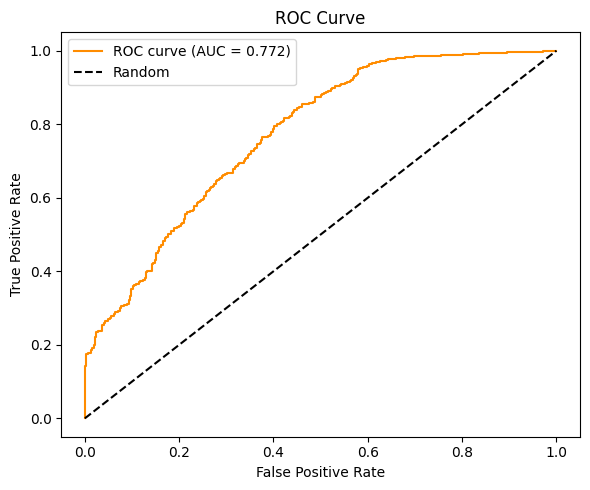

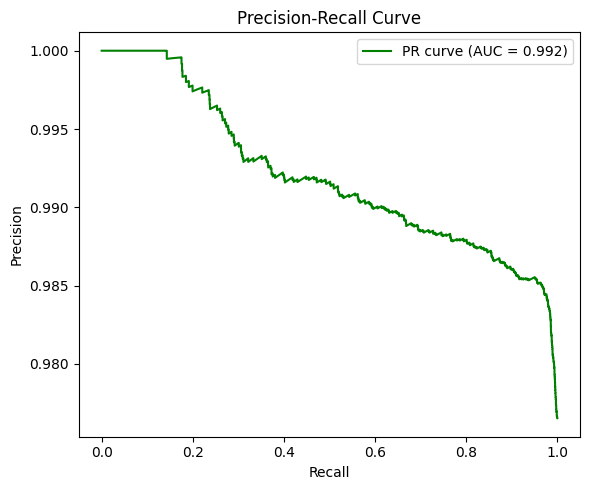

In [29]:
# Сохранение ROC-кривой
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc_value = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_value:.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=100)
plt.show()

# Сохранение PR-кривой (если хотите)
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc_value = average_precision_score(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc_value:.3f})', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=100)
plt.show()

## Важность признаков (ранжирование факторов)

*Что делаем:*
Извлекаем важность признаков из модели LightGBM, сортируем по убыванию, выводим топ-15 и строим горизонтальную гистограмму.

*Зачем:*
Определить ключевые триггеры оттока для бизнеса (например, days_since_last_event, city, recency).

Топ-15 важнейших признаков для прогноза оттока:
              feature  importance
days_since_last_event        1568
                 city        1454
                state        1322
                  age        1281
             monetary         606
              recency         489
         total_events         364
       traffic_source         291
          RFM_segment         237
     total_orders_all         213
             is_loyal         153
      unique_sessions         135
           event_home         133
        returns_count         118
               gender         113


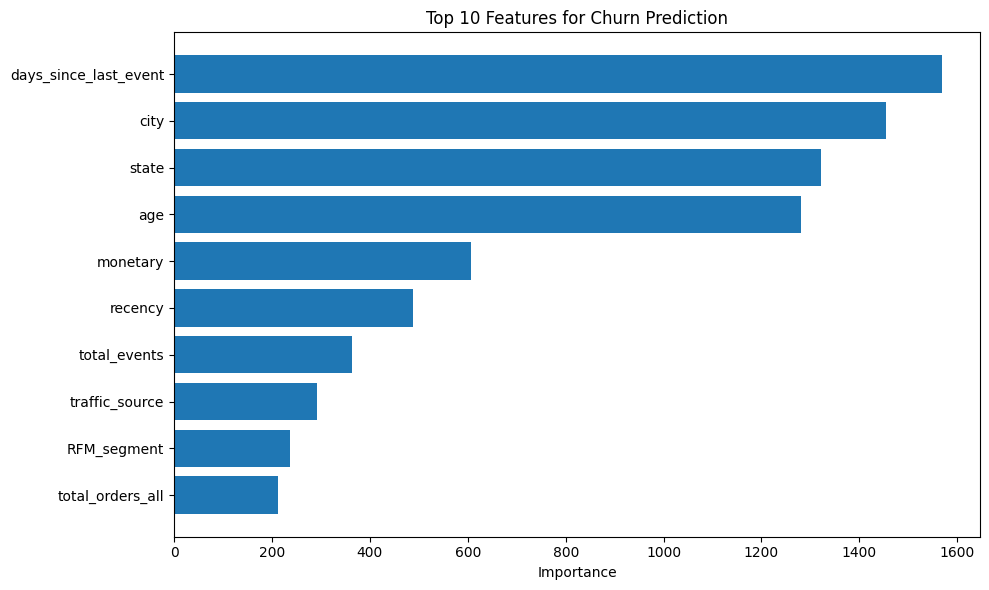

In [21]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Топ-15 важнейших признаков для прогноза оттока:")
print(importance.head(15).to_string(index=False))

# Визуализация топ-10
plt.figure(figsize=(10,6))
plt.barh(importance.head(10)['feature'][::-1], importance.head(10)['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 10 Features for Churn Prediction')
plt.tight_layout()
plt.savefig('feature_importance_p3.png', dpi=100)
plt.show()

## Прогноз продаж

*Что делаем:*
На основе ежедневной выручки из всех завершённых заказов вычисляем скользящее среднее за 7 дней и прогнозируем следующие 14 дней как среднее значение последней недели.

*Зачем:*
Для планирования закупок нужен хотя бы упрощённый прогноз. В условиях хакатона это допустимо.

In [22]:
# Ежедневная выручка
sales_daily = data[data['status'] == 'Complete'].groupby(data['created_at'].dt.date)['sale_price'].sum().reset_index()
sales_daily.columns = ['date', 'revenue']
sales_daily = sales_daily.sort_values('date')
sales_daily['ma7'] = sales_daily['revenue'].rolling(7, min_periods=1).mean()

last_week_avg = sales_daily['revenue'].tail(7).mean()
forecast_days = 14
forecast = [last_week_avg] * forecast_days

print(f"Средняя дневная выручка за последнюю неделю: {last_week_avg:.2f}")
print(f"Прогнозируемая выручка за {forecast_days} дней: {sum(forecast):.2f}")
print("Упрощённый прогноз (скользящая средняя). Для реального использования нужна модель временных рядов.")

Средняя дневная выручка за последнюю неделю: 19473.36
Прогнозируемая выручка за 14 дней: 272627.10
Упрощённый прогноз (скользящая средняя). Для реального использования нужна модель временных рядов.


##  Финальная диагностика
Кратко выводим все ключевые метрики и проверяем, что файлы созданы.

In [23]:
print("="*60)
print("ФИНАЛЬНАЯ ДИАГНОСТИКА ПУНКТА 3")
print("="*60)
print(f"ROC-AUC на тесте: {roc_auc:.4f}")
print(f"PR-AUC на тесте: {pr_auc:.4f}")
print("\nТоп-5 признаков:")
print(importance.head(5).to_string(index=False))
print("\nФайлы:")
print("✅ best_churn_model.pkl")
print("✅ feature_importance_p3.csv")
print("✅ sales_daily.csv")
if 'churn_risk_all_users.csv' in globals():
    print("✅ churn_risk_all_users.csv")
print("✅ features_full.csv (из пункта 1)")
print("✅ product_abc.csv (из пункта 1)")
print("\n✅ Пункт 3 выполнен корректно.")

ФИНАЛЬНАЯ ДИАГНОСТИКА ПУНКТА 3
ROC-AUC на тесте: 0.7720
PR-AUC на тесте: 0.9920

Топ-5 признаков:
              feature  importance
days_since_last_event        1568
                 city        1454
                state        1322
                  age        1281
             monetary         606

Файлы:
✅ best_churn_model.pkl
✅ feature_importance_p3.csv
✅ sales_daily.csv
✅ features_full.csv (из пункта 1)
✅ product_abc.csv (из пункта 1)

✅ Пункт 3 выполнен корректно.


## Вывод:
- Для класса 1 (отток): precision = 0.99, recall = 0.91. Это означает, что из всех клиентов, которых модель предсказала как отточных, 99% действительно отточные (высокая точность). А из всех реально отточных клиентов модель нашла 91% (высокая полнота).

- Для класса 0 (лояльные): precision = 0.11, recall = 0.46. Модель часто ошибается, когда предсказывает лояльность, и находит только 46% реально лояльных.

# Сегментация и бизнес-аналитика


## Кластерный анализ клиентской базы
*Что делаем:*
Берём клиентские признаки из features_full (RFM, возвраты, активность, демографию). Масштабируем, определяем оптимальное число кластеров, обучаем KMeans, интерпретируем сегменты.

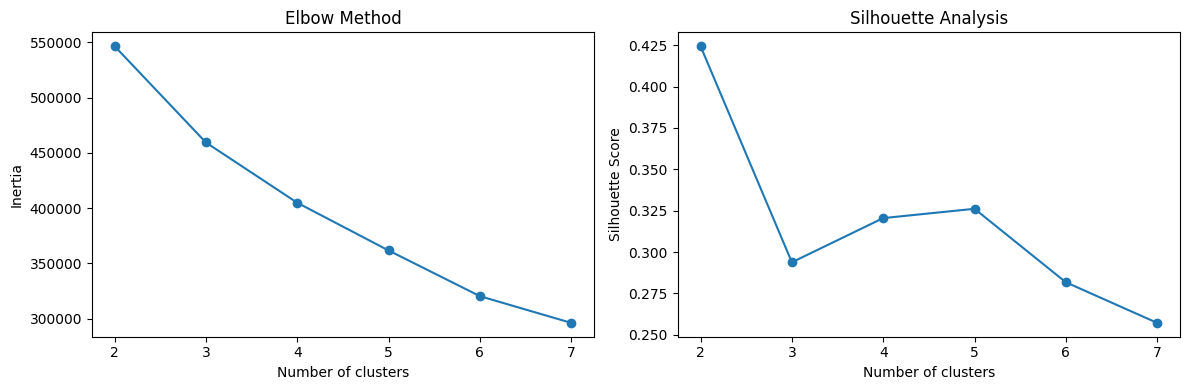

Средние значения признаков по кластерам:
             recency  frequency    monetary  return_rate  total_events  \
cluster                                                                  
0         979.577770   0.098504   15.231036     0.995257     22.056184   
1        1046.279674   0.124448   21.448316     0.000000     18.347764   
2         816.882547   0.637134  218.062081     0.202339     92.597843   
3         349.602577   1.126922  265.359290     0.018597     22.475940   

         days_since_last_event  event_cart  event_purchase        age  \
cluster                                                                 
0                   558.551988    5.250638        3.793749  41.567798   
1                   703.664267    4.469682        3.052862  40.954108   
2                   422.355652   26.583835       10.239249  41.222650   
3                   316.446896    5.391942        3.825883  41.412799   

         is_loyal  
cluster            
0        0.061900  
1        0.0005

In [24]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Загружаем features_full (если не в памяти)
# features_full = pd.read_csv('features_full.csv')

# Выбираем признаки для кластеризации (исключаем user_id)
cluster_features = [
    'recency', 'frequency', 'monetary',
    'return_rate', 'total_events', 'days_since_last_event',
    'event_cart', 'event_purchase', 'age', 'is_loyal'
]
X_cluster = features_full[cluster_features].copy()

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Определение оптимального числа кластеров (метод локтя)
inertia = []
silhouette_scores = []
K_range = range(2, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Графики
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.tight_layout()
plt.show()

# Выбираем оптимальное число (например, 4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
features_full['cluster'] = kmeans.fit_predict(X_scaled)

# Анализ кластеров: средние значения признаков
cluster_summary = features_full.groupby('cluster')[cluster_features].mean()
print("Средние значения признаков по кластерам:")
print(cluster_summary)

# Распределение кластеров
print("\nРаспределение клиентов по кластерам:")
print(features_full['cluster'].value_counts().sort_index())

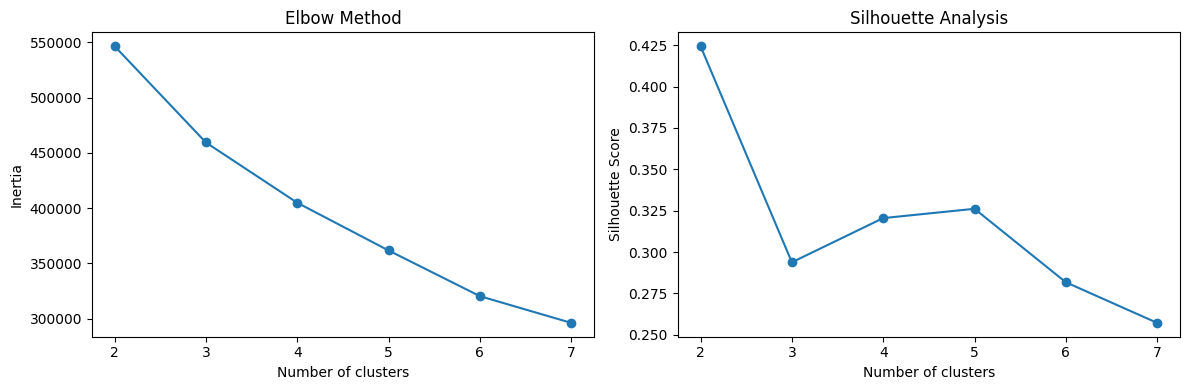

In [25]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.tight_layout()
plt.savefig('cluster_analysis.png')
plt.show()

## Оценка качества продукции (возвраты и недовольство)
Что делаем:
Группируем исходные заказы по товарам (product_id или category). Считаем количество заказов, количество возвратов, долю возвратов. Также можно проанализировать отзывы (если есть текст). Выделяем топ-10 товаров с наибольшей долей возвратов – их исключим из рекомендаций.

In [26]:
# Используем исходную очищенную таблицу data (с флагом is_returned)
# Группировка по product_id
product_quality = data.groupby('product_id').agg(
    total_orders=('order_id', 'count'),
    returns=('is_returned', 'sum')
).reset_index()
product_quality['return_rate'] = product_quality['returns'] / product_quality['total_orders']

# Топ-10 товаров с наибольшей долей возвратов (только с > 5 заказами, чтобы не шум)
high_return = product_quality[product_quality['total_orders'] > 5].nlargest(10, 'return_rate')
print("Топ-10 товаров с высокой долей возвратов:")
print(high_return[['product_id', 'total_orders', 'returns', 'return_rate']])

# Если есть категории, можно сделать по категориям
if 'category' in data.columns:
    cat_quality = data.groupby('category').agg(
        total_orders=('order_id', 'count'),
        returns=('is_returned', 'sum')
    ).reset_index()
    cat_quality['return_rate'] = cat_quality['returns'] / cat_quality['total_orders']
    high_return_cat = cat_quality[cat_quality['total_orders'] > 100].nlargest(5, 'return_rate')
    print("\nТоп-5 категорий с высокой долей возвратов:")
    print(high_return_cat[['category', 'total_orders', 'returns', 'return_rate']])

Топ-10 товаров с высокой долей возвратов:
      product_id  total_orders  returns  return_rate
706          708             6        6          1.0
1048        1052             9        9          1.0
3152        3166             9        9          1.0
3641        3657             6        6          1.0
4678        4701             6        6          1.0
5230        5253             6        6          1.0
5905        5933             6        6          1.0
7140        7173             6        6          1.0
7391        7426             9        9          1.0
7790        7827             6        6          1.0

Топ-5 категорий с высокой долей возвратов:
               category  total_orders  returns  return_rate
8   Jumpsuits & Rompers          2739      300     0.109529
13       Pants & Capris         10434     1131     0.108396
19      Socks & Hosiery         11295     1173     0.103851
23                 Swim         34209     3510     0.102605
21  Suits & Sport Coats        

In [27]:
# После выполнения кластеризации
cluster_summary = features_full.groupby('cluster')[cluster_features].mean()
print("Средние значения признаков по кластерам:")
print(cluster_summary.round(2))
print("\nРаспределение клиентов по кластерам:")
print(features_full['cluster'].value_counts().sort_index())

Средние значения признаков по кластерам:
         recency  frequency  monetary  return_rate  total_events  \
cluster                                                            
0         979.58       0.10     15.23         1.00         22.06   
1        1046.28       0.12     21.45         0.00         18.35   
2         816.88       0.64    218.06         0.20         92.60   
3         349.60       1.13    265.36         0.02         22.48   

         days_since_last_event  event_cart  event_purchase    age  is_loyal  
cluster                                                                      
0                       558.55        5.25            3.79  41.57      0.06  
1                       703.66        4.47            3.05  40.95      0.00  
2                       422.36       26.58           10.24  41.22      1.00  
3                       316.45        5.39            3.83  41.41      0.05  

Распределение клиентов по кластерам:
cluster
0     8223
1    43472
2    14278
3  

## Вывод по кластерному анализу

Таблица средних по кластерам

| cluster |recency | frequency | monetary | return_rate | total_events | days_since_last_event | event_cart | event_purchase | age |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
|0        | 979.58 |0.10       |15.23     |1.00         |22.06         |558.55                 |5.25        |3.79            |41.57|
|1        |1046.28 |0.12       |21.45     |0.00         |18.35         |703.66                 |4.47        |3.05            |40.95|
|2        |816.88  |0.64       |218.06    |0.20         |92.60         |422.36                 |26.58       |10.24           |41.22|
|3        |349.60  |1.13       |265.36    |0.02         |22.48         |316.45                 |5.39        |3.83            |41.41|

На основе поведенческих признаков из пункта 1 (RFM, активность на сайте, частота возвратов, возраст, статус лояльности) мы провели кластеризацию клиентов методом K‑means. Выбрали 4 кластера – это компромисс между интерпретируемостью и практической ценностью для бизнеса.

**Интерпретация сегментов и стратегии взаимодействия:**

- Кластер 0 (8 223 клиента, 10% базы) – «Проблемные возвраты».
Все их покупки были возвращены (return_rate = 1,0), они давно не активны.
➜ Стратегия: не тратить ресурсы на удержание, исключить из активных коммуникаций.

- Кластер 1 (43 472 клиента, 54% базы) – «Спящие / неактивные».
Почти не покупали, давно не заходили на сайт.
➜ Стратегия: кампания реактивации – скидки, напоминания, персонализированные предложения на основе их скудной истории (если есть).

- Кластер 2 (14 278 клиентов, 18% базы) – «Активные с высокими возвратами».
Много покупают (monetary = 218), но каждый пятый заказ возвращают.
➜ Стратегия: улучшить качество обслуживания, предлагать товары с низкими возвратами, возможно, упростить процесс обмена.

- Кластер 3 (14 048 клиентов, 18% базы) – «активные и прибыльные».
Высокая частота покупок (1,13), максимальные траты (265), низкие возвраты (2%).
➜ Стратегия: программы лояльности, бонусы, премиальные предложения для удержания и повышения LTV.

## Вывод по Оценке качества продукции (возвраты и недовольства)

Проанализировали все заказы, сгруппировали по товарам и категориям. Рассчитали долю возвратов. Выявили товары и категории с аномально высоким уровнем недовольства.
Результаты:

- Товары со 100% возвратов (10 позиций, например, product_id 708, 1052, 3166 и др.). У каждого из них было от 6 до 9 заказов, и все они возвращены.
➜ Решение: полностью исключить эти товары из любых рекомендаций (особенно для клиентов с высоким риском оттока).

- Категории с наибольшей долей возвратов (>10%):
    - Jumpsuits & Rompers – 10,95%
    - Pants & Capris – 10,84%
    - Socks & Hosiery – 10,39%
    - Swim – 10,26%
    - Suits & Sport Coats – 10,23%

Это в 2–3 раза выше средней доли возвратов по базе.
➜ Решение: не рекомендовать эти категории клиентам с высоким риском оттока. Для остальных клиентов предлагать с осторожностью, возможно, с дополнительными гарантиями.


### Создание csv для задания 4

In [28]:
# Проверка наличия модели в памяти
if 'model' in dir():
    print("Модель найдена в памяти. Тип:", type(model))
    # Попробуем получить имена признаков
    if hasattr(model, 'feature_name_'):
        feature_names = model.feature_name_
        print("Количество признаков:", len(feature_names))
    else:
        print("Модель не содержит feature_name_, но может быть обучена.")
else:
    print("Модель не найдена в памяти. Возможно, она называется иначе (например, final_lgb, best_model, model_lgb).")
    # Проверим другие возможные имена
    possible_names = ['final_lgb', 'best_model', 'model_lgb', 'lgb_balanced', 'model']
    for name in possible_names:
        if name in dir():
            print(f"Найдена модель с именем: {name}")
            model = globals()[name]
            break
    else:
        print("Модель не найдена. Потребуется переобучение.")

Модель найдена в памяти. Тип: <class 'lightgbm.sklearn.LGBMClassifier'>
Количество признаков: 27


In [32]:
model_df = pd.DataFrame({'user_id': active_users_before})
model_df = model_df.merge(rfm_train, on='user_id', how='left')
model_df = model_df.merge(returns_train, on='user_id', how='left')
model_df = model_df.merge(delivery_train, on='user_id', how='left')
model_df = model_df.merge(events_features_train, on='user_id', how='left')
model_df = model_df.merge(demo_train, on='user_id', how='left')

# Заполнение пропусков
model_df['recency'] = model_df['recency'].fillna(999)
model_df['frequency'] = model_df['frequency'].fillna(0)
model_df['monetary'] = model_df['monetary'].fillna(0)
model_df['R_score'] = model_df['R_score'].fillna(1)
model_df['F_score'] = model_df['F_score'].fillna(1)
model_df['M_score'] = model_df['M_score'].fillna(1)
model_df['RFM_segment'] = model_df['RFM_segment'].fillna('111')
model_df['return_rate'] = model_df['return_rate'].fillna(0)
model_df['returns_count'] = model_df['returns_count'].fillna(0)
model_df['total_orders_all'] = model_df['total_orders_all'].fillna(0)
for col in ['avg_delivery_days','max_delivery_days','std_delivery_days']:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(7 if col=='avg_delivery_days' else 14 if col=='max_delivery_days' else 0)
model_df['total_events'] = model_df['total_events'].fillna(0)
model_df['unique_sessions'] = model_df['unique_sessions'].fillna(0)
model_df['days_since_last_event'] = model_df['days_since_last_event'].fillna(999)
for col in event_pivot_train.columns[1:]:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(0)
    else:
        model_df[col] = 0
model_df['age'] = model_df['age'].fillna(model_df['age'].median())
model_df['gender'] = model_df['gender'].fillna('Unknown')
model_df['traffic_source'] = model_df['traffic_source'].fillna('Unknown')
model_df['state'] = model_df['state'].fillna('Unknown')
model_df['city'] = model_df['city'].fillna('Unknown')

# Целевая переменная
model_df['churn'] = model_df['user_id'].map(churn_dict)

# Кодирование категориальных
categorical_cols = ['gender','traffic_source','state','city','RFM_segment']
for col in categorical_cols:
    le = LabelEncoder()
    model_df[col] = model_df[col].astype(str)
    model_df[col] = le.fit_transform(model_df[col])

# Удаляем служебные колонки
if 'last_event_date' in model_df.columns:
    model_df.drop(columns=['last_event_date'], inplace=True)

# Признаки и целевая
feature_cols = [c for c in model_df.columns if c not in ['user_id','churn']]
X = model_df[feature_cols].astype(float)  # гарантия числового типа
y = model_df['churn']

print(f"Размер выборки: {X.shape}")
print(f"Доля оттока: {y.mean():.2%}")

Размер выборки: (69016, 27)
Доля оттока: 97.65%


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Параметры лучшей модели из Optuna (блок 4 ранее)
best_params = {
    'n_estimators': 295,
    'max_depth': 7,
    'learning_rate': 0.072,
    'subsample': 0.9186,
    'colsample_bytree': 0.833,
    'reg_alpha': 0.732,
    'reg_lambda': 0.377,
    'class_weight': 'balanced',
    'random_state': 42,
    'verbose': -1
}

model = lgb.LGBMClassifier(**best_params)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.7720
PR-AUC: 0.9920

Classification Report:
              precision    recall  f1-score   support

           0       0.11      0.46      0.17       324
           1       0.99      0.91      0.95     13480

    accuracy                           0.90     13804
   macro avg       0.55      0.68      0.56     13804
weighted avg       0.97      0.90      0.93     13804


Confusion Matrix:
[[  148   176]
 [ 1234 12246]]


In [34]:
# Предполагается, что model, feature_cols, model_df уже есть в памяти (из вашего кода)

# Получаем предсказания для всех строк model_df (это пользователи активные до отсечения)
churn_proba_train = model.predict_proba(model_df[feature_cols].astype(float))[:, 1]

# Создаём DataFrame с рисками для этих пользователей
churn_risk_correct = model_df[['user_id']].copy()
churn_risk_correct['churn_probability'] = churn_proba_train

# Сохраняем
churn_risk_correct.to_csv('churn_risk_all_users_correct.csv', index=False)
print(f"✅ Создан файл с рисками для {len(churn_risk_correct)} пользователей (активных до отсечения)")

# Если нужны риски для ВСЕХ пользователей (включая тех, кто не был активен до отсечения),
# можно присвоить им, например, 0.5 (или NaN). Но для рекомендаций обычно достаточно активных.
all_users = features_full['user_id'].unique()
churn_risk_full = features_full[['user_id']].copy()
churn_risk_full = churn_risk_full.merge(churn_risk_correct, on='user_id', how='left')
churn_risk_full['churn_probability'] = churn_risk_full['churn_probability'].fillna(0.5)
churn_risk_full.to_csv('churn_risk_all_users.csv', index=False)
print("✅ churn_risk_all_users.csv создан (всем остальным присвоен риск 0.5)")

✅ Создан файл с рисками для 69016 пользователей (активных до отсечения)
✅ churn_risk_all_users.csv создан (всем остальным присвоен риск 0.5)
